In [1]:
import os
from pathlib import Path

# Walk up until we find the repo root (identified by CLAUDE.md)
_here = Path(os.getcwd())
while not (_here / "CLAUDE.md").exists() and _here != _here.parent:
    _here = _here.parent
os.chdir(_here)
del _here

import duckdb
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from scipy.stats import sem

%matplotlib inline

Path("results").mkdir(exist_ok=True)
Path("results/plots").mkdir(exist_ok=True)

DARK  = "#2c3e50"; MID  = "#7f8c8d"; GOLD  = "#e8b84b"
RED   = "#e74c3c"; BLUE = "#3498db"; GREEN = "#27ae60"; BG = "#f8f8f8"

MIN_SWINGS = 200
COMMIT_MS  = 150

# Empirical baseline columns: expected plate location from KNN on commit-time state
EMP_DEV_X   = f"pc{COMMIT_MS}_emp_dev_x"    # actual - KNN-expected plate_x
EMP_DEV_Z   = f"pc{COMMIT_MS}_emp_dev_z"    # actual - KNN-expected plate_z
EMP_X_PROJ  = f"pc{COMMIT_MS}_emp_x_proj"   # KNN-expected plate_x
EMP_Z_PROJ  = f"pc{COMMIT_MS}_emp_z_proj"   # KNN-expected plate_z

# Gravity-corrected linear deviation (spin-induced only, gravity stripped out)
LIN_DEV_X   = f"pc{COMMIT_MS}_dev_x"
LIN_DEV_Z   = f"pc{COMMIT_MS}_dev_z"

# Primary treatment columns used throughout (empirical baseline)
DEV_X = EMP_DEV_X
DEV_Z = EMP_DEV_Z

AXIS_COLS  = ("vert_attack_angle_dev", "horz_attack_angle_dev", "swing_path_tilt_dev")
AXIS_LBL   = {"vert_attack_angle_dev": "VAA",
              "horz_attack_angle_dev": "HAA",
              "swing_path_tilt_dev":   "Tilt"}


def _spine_clean(ax):
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color(MID)
    ax.spines["bottom"].set_color(MID)


def _eb_shrink(means, ns, within_var, between_var, grand):
    w = ns / (ns + within_var / between_var)
    return w * means + (1 - w) * grand

Path("results/plots/leaderboards").mkdir(parents=True, exist_ok=True)
Path("results/plots/validation").mkdir(parents=True, exist_ok=True)
Path("results/plots/diagnostics").mkdir(parents=True, exist_ok=True)
Path("results/plots/case_studies").mkdir(parents=True, exist_ok=True)


In [2]:
_cache = {}


def _load(key, fn):
    if key not in _cache:
        _cache[key] = fn()
    return _cache[key]


_PC_COLS = ", ".join([
    "game_pk", "at_bat_number", "pitch_number", "game_year",
    # Empirical baseline (KNN commit-time expected plate location)
    EMP_DEV_X, EMP_DEV_Z, EMP_X_PROJ, EMP_Z_PROJ,
    # Gravity-corrected linear deviation (spin-induced only)
    LIN_DEV_X, LIN_DEV_Z,
    "ball_bat_miss", "is_whiff",
    "is_contact", "is_bip", "is_single", "is_double", "is_triple", "is_home_run",
    "is_swing", "bat_speed", "count_group", "balls", "strikes", "vert_attack_angle",
    "pitcher_full_name", "pitch_type", "pfx_x", "pfx_z",
    f"pc{COMMIT_MS}_R_x", f"pc{COMMIT_MS}_R_y", f"pc{COMMIT_MS}_R_z",
    f"pc{COMMIT_MS}_V_x", f"pc{COMMIT_MS}_V_y", f"pc{COMMIT_MS}_V_z",
    f"pc{COMMIT_MS}_A_x", f"pc{COMMIT_MS}_A_y", f"pc{COMMIT_MS}_A_z",
    f"pc{COMMIT_MS}_t_plate",
])

_SXRV_COLS = ", ".join([
    "game_pk", "at_bat_number", "pitch_number", "pitcher_id", "pitcher_full_name",
    "pfx_x", "pfx_z", "release_speed", "release_extension", "arm_angle",
    "ivb_transverse", "hb_transverse", "pitcher_throws", "stuff_grade", "xrv_vs_count", "xrv",
])


def xrv():  return _load("xrv",  lambda: duckdb.sql("SELECT * FROM read_parquet('results/xrv_causal.parquet')").df())
def pc():   return _load("pc",   lambda: duckdb.sql(f"SELECT {_PC_COLS} FROM read_parquet('data/swings_precommit.parquet')").df())
def sxrv(): return _load("sxrv", lambda: duckdb.sql(f"SELECT {_SXRV_COLS} FROM read_parquet('results/swing_xrv.parquet')").df())


def merged():
    if "merged" in _cache:
        return _cache["merged"]
    pc_cols = ["game_pk", "at_bat_number", "pitch_number", "game_year",
               EMP_DEV_X, EMP_DEV_Z, LIN_DEV_X, LIN_DEV_Z, "ball_bat_miss", "is_whiff"]
    sx_cols = ["game_pk", "at_bat_number", "pitch_number", "pitcher_full_name",
               "pfx_x", "pfx_z", "release_speed", "release_extension", "arm_angle",
               "ivb_transverse", "hb_transverse", "pitcher_throws",
               "stuff_grade", "xrv_vs_count", "xrv"]
    K = ["game_pk", "at_bat_number", "pitch_number"]
    df = (xrv()
          .merge(pc()[pc_cols], on=K, how="left")
          .merge(sxrv()[sx_cols], on=K, how="left"))
    _cache["merged"] = df
    return df


# Empirical Baseline

In [3]:
"""
Empirical Baseline Diagnostics
================================
EMP_DEV_X / EMP_DEV_Z (pc150_emp_dev_x / pc150_emp_dev_z):
  How far the pitch's actual plate location deviated from where the batter
  should have expected it, given this pitcher's historical pitches that had
  the most similar commit-time trajectory (position + velocity at 150 ms
  before contact). Computed with K=50 nearest neighbors per pitcher (LOO).

  Positive emp_dev_x = ball ended up further inside (right-handed frame).
  Positive emp_dev_z = ball ended up higher than expected.

LIN_DEV_X / LIN_DEV_Z (pc150_dev_x / pc150_dev_z):
  The older treatment: deviation from a straight-line (constant velocity)
  extrapolation from the commit point, with gravity stripped out so only
  spin-induced movement counts. Still proportional to pfx.

The empirical baseline is the preferred treatment. It captures actual
pitch-mix deception: a curveball that already looks like a curveball at
commit gets a small emp_dev (other curveballs from this pitcher with that
same commit state also end up low and away). A cutter that looks identical
to a fastball at commit gets a large emp_dev.
"""

df = pc().copy()
df = df[df[EMP_DEV_X].notna() & df[EMP_DEV_Z].notna()]

# ── Table 1: Overall summary ─────────────────────────────────────────────────
print("=" * 65)
print("Table 1: Empirical vs Linear Deviation — Overall Summary")
print("=" * 65)
print(f"{'Metric':<28} {'Mean (ft)':>10} {'Std (ft)':>10} {'p5 (ft)':>10} {'p95 (ft)':>10}")
print("-" * 65)
for label, col in [
    ("emp_dev_x (horizontal)",  EMP_DEV_X),
    ("emp_dev_z (vertical)",    EMP_DEV_Z),
    ("emp_dev_total (|x,z|)",   None),
    ("lin_dev_x (horizontal)",  LIN_DEV_X),
    ("lin_dev_z (vertical)",    LIN_DEV_Z),
]:
    if col is None:
        vals = np.sqrt(df[EMP_DEV_X]**2 + df[EMP_DEV_Z]**2)
    else:
        vals = df[col].dropna()
    print(f"  {label:<26} {vals.mean():>10.4f} {vals.std():>10.4f} "
          f"{vals.quantile(0.05):>10.4f} {vals.quantile(0.95):>10.4f}")
print(f"\n  Coverage (rows with emp_dev): {df[EMP_DEV_X].notna().mean():.1%} of swings")


Table 1: Empirical vs Linear Deviation — Overall Summary
Metric                        Mean (ft)   Std (ft)    p5 (ft)   p95 (ft)
-----------------------------------------------------------------
  emp_dev_x (horizontal)         0.0024     0.1914    -0.2961     0.3009
  emp_dev_z (vertical)          -0.0084     0.1176    -0.1510     0.1235
  emp_dev_total (|x,z|)          0.1569     0.1610     0.0230     0.4758
  lin_dev_x (horizontal)        -0.0260     0.1230    -0.2083     0.1782
  lin_dev_z (vertical)           0.0921     0.0977    -0.0742     0.2377

  Coverage (rows with emp_dev): 100.0% of swings


In [4]:
# ── Table 2: By pitch type ───────────────────────────────────────────────────
"""
Table 2: Empirical vs Linear Deviation by Pitch Type
------------------------------------------------------
emp_dev_total = sqrt(emp_dev_x² + emp_dev_z²)
  How surprising the pitch location was from the batter's perspective,
  given this pitcher's pitch mix at the commit point.

lin_dev_total = sqrt(lin_dev_x² + lin_dev_z²)
  The gravity-corrected spin-induced deviation (roughly proportional to pfx).

If emp_dev and lin_dev were the same thing, their ratio would be constant
across pitch types. A curveball should have a SMALLER emp_dev relative to
lin_dev than a cutter, because curveballs give themselves away earlier.
"""

df = pc().copy()
df = df[df[EMP_DEV_X].notna() & df[LIN_DEV_X].notna() & df["pitch_type"].notna()]
df["emp_dev_total"] = np.sqrt(df[EMP_DEV_X]**2 + df[EMP_DEV_Z]**2)
df["lin_dev_total"] = np.sqrt(df[LIN_DEV_X]**2 + df[LIN_DEV_Z]**2)

PITCH_NAMES = {
    "FF": "4-Seam Fastball", "SI": "Sinker",    "FC": "Cutter",
    "CH": "Changeup",        "FS": "Splitter",  "SL": "Slider",
    "CU": "Curveball",       "ST": "Sweeper",   "KC": "Knuckle-curve",
}

pt_agg = (
    df[df["pitch_type"].isin(PITCH_NAMES)]
    .groupby("pitch_type")
    .agg(
        n          =(EMP_DEV_X,      "size"),
        emp_dev_x  =(EMP_DEV_X,      "mean"),
        emp_dev_z  =(EMP_DEV_Z,      "mean"),
        emp_dev_tot=("emp_dev_total", "mean"),
        lin_dev_x  =(LIN_DEV_X,      "mean"),
        lin_dev_z  =(LIN_DEV_Z,      "mean"),
        lin_dev_tot=("lin_dev_total", "mean"),
    )
    .query("n >= 1000")
    .assign(name=lambda d: d.index.map(PITCH_NAMES))
    .assign(emp_vs_lin=lambda d: d["emp_dev_tot"] / d["lin_dev_tot"])
    .sort_values("emp_dev_tot", ascending=False)
)

print("=" * 95)
print("Table 2: Empirical vs Linear Deviation by Pitch Type  (mean absolute deviation, feet)")
print("=" * 95)
print(f"  {'Type':<18} {'n':>8}  {'emp_dev_x':>10} {'emp_dev_z':>10} {'emp_total':>10}"
      f"  {'lin_dev_x':>10} {'lin_dev_z':>10} {'lin_total':>10}  {'emp/lin':>8}")
print("-" * 95)
for pt, row in pt_agg.iterrows():
    print(f"  {row['name']:<18} {int(row['n']):>8}  "
          f"{row['emp_dev_x']:>10.4f} {row['emp_dev_z']:>10.4f} {row['emp_dev_tot']:>10.4f}  "
          f"{row['lin_dev_x']:>10.4f} {row['lin_dev_z']:>10.4f} {row['lin_dev_tot']:>10.4f}  "
          f"{row['emp_vs_lin']:>8.3f}")
print()
print("  emp/lin < 1.0 means the pitch type is more predictable than its raw movement suggests.")
print("  emp/lin > 1.0 means the pitch type is more deceptive than its raw movement suggests.")


Table 2: Empirical vs Linear Deviation by Pitch Type  (mean absolute deviation, feet)
  Type                      n   emp_dev_x  emp_dev_z  emp_total   lin_dev_x  lin_dev_z  lin_total   emp/lin
-----------------------------------------------------------------------------------------------
  Sweeper               51550      0.0674    -0.0526     0.2112      0.0655     0.0111     0.1236     1.708
  Curveball             42840      0.0014    -0.0633     0.1968      0.0345    -0.0837     0.1184     1.663
  Knuckle-curve         12420      0.0109    -0.0534     0.1801      0.0463    -0.0839     0.1088     1.656
  Slider               116120      0.0446    -0.0538     0.1786      0.0179     0.0216     0.0605     2.950
  Changeup              85517     -0.0287    -0.0667     0.1644     -0.0479     0.0528     0.1696     0.969
  Splitter              25119     -0.0444    -0.0676     0.1602     -0.1030     0.0356     0.1354     1.183
  Cutter                62450      0.0387    -0.0024     0.148

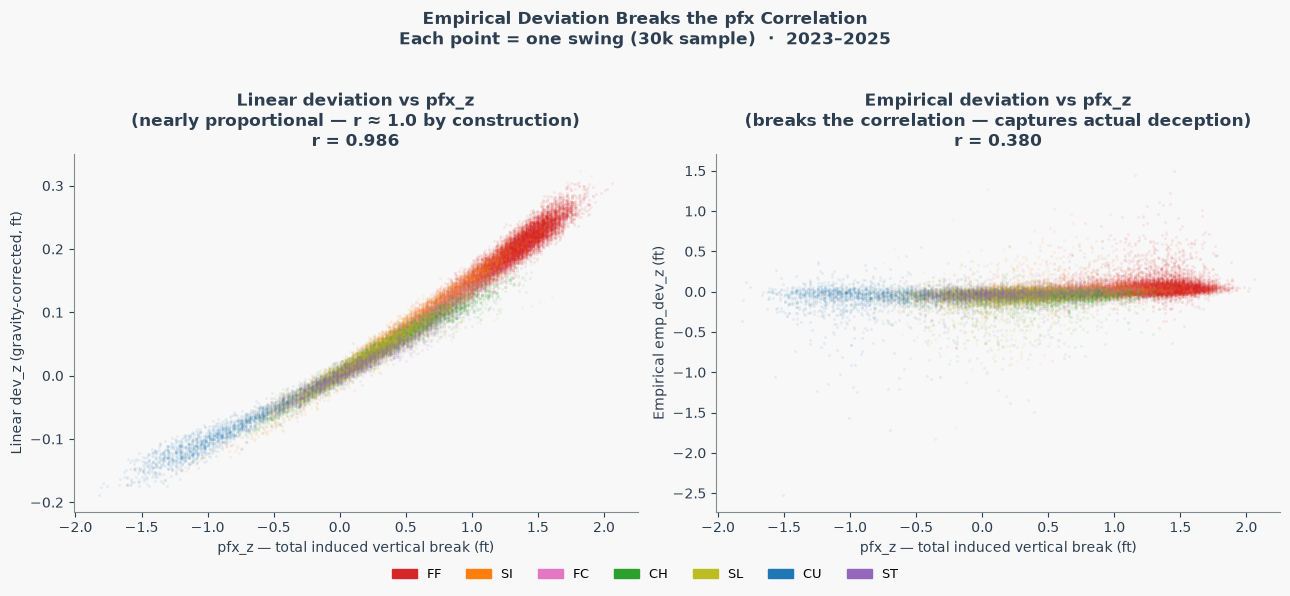

Saved results/plots/diagnostics/empirical_vs_linear_deviation.png

Key: left panel r ≈ 1 confirms lin_dev is just scaled pfx.
     right panel r < 1 shows emp_dev captures deception beyond raw movement.


In [5]:
# ── Figure: emp_dev_z vs pfx_z, colored by pitch type ───────────────────────
"""
This plot shows why the empirical baseline is different from the old treatment.

Old treatment (lin_dev_z) is almost perfectly correlated with pfx_z — it's
just pfx scaled by a constant (tau/t_plate)^2. Every curveball ranks high
on distortion regardless of whether the batter was actually surprised.

Empirical baseline (emp_dev_z) breaks that correlation. A pitcher whose
curveballs all look the same from the commit point gets a low emp_dev_z on
those curveballs even if pfx is large. The residual — pitches with high
emp_dev relative to pfx — is where actual deception lives.
"""
import matplotlib.ticker as mticker

df = pc().copy()
df = df[df[EMP_DEV_Z].notna() & df["pfx_z"].notna() & df["pitch_type"].notna()]

PLOT_TYPES = {"FF": "#d62728", "SI": "#ff7f0e", "FC": "#e377c2",
              "CH": "#2ca02c", "SL": "#bcbd22", "CU": "#1f77b4",
              "ST": "#9467bd"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)
fig.patch.set_facecolor(BG)

for ax, y_col, y_label, title in [
    (axes[0], LIN_DEV_Z, "Linear dev_z (gravity-corrected, ft)",
     "Linear deviation vs pfx_z\n(nearly proportional — r ≈ 1.0 by construction)"),
    (axes[1], EMP_DEV_Z, "Empirical emp_dev_z (ft)",
     "Empirical deviation vs pfx_z\n(breaks the correlation — captures actual deception)"),
]:
    ax.set_facecolor(BG)
    sub = df[df["pitch_type"].isin(PLOT_TYPES)].sample(min(30_000, len(df)), random_state=42)
    for pt, color in PLOT_TYPES.items():
        s = sub[sub["pitch_type"] == pt]
        ax.scatter(s["pfx_z"], s[y_col], alpha=0.08, s=5, c=color, linewidths=0, label=pt)
    r = sub[["pfx_z", y_col]].dropna().corr().iloc[0, 1]
    ax.set_xlabel("pfx_z — total induced vertical break (ft)", color=DARK)
    ax.set_ylabel(y_label, color=DARK)
    ax.set_title(title + f"\nr = {r:.3f}", color=DARK, fontweight="bold")
    _spine_clean(ax)
    ax.tick_params(colors=DARK)

# shared legend
handles = [mpatches.Patch(color=c, label=pt) for pt, c in PLOT_TYPES.items()]
fig.legend(handles=handles, loc="lower center", ncol=7,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    "Empirical Deviation Breaks the pfx Correlation\n"
    "Each point = one swing (30k sample)  ·  2023–2025",
    fontsize=12, fontweight="bold", color=DARK, y=1.02,
)
fig.tight_layout()
out = "results/plots/diagnostics/empirical_vs_linear_deviation.png"
Path("results/plots/diagnostics").mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out}")
print(f"\nKey: left panel r ≈ 1 confirms lin_dev is just scaled pfx.")
print(f"     right panel r < 1 shows emp_dev captures deception beyond raw movement.")


In [6]:
# ── Table 3: Pitcher predictability — most vs least surprising pitch mixes ───
"""
Table 3: Pitcher Predictability
---------------------------------
mean_emp_dev_total = sqrt(emp_dev_x² + emp_dev_z²), averaged per pitcher.

High mean_emp_dev: pitcher's pitches end up far from where their commit-time
  trajectory would suggest — genuinely deceptive at commit.

Low mean_emp_dev: pitcher's pitches are predictable from commit — same trajectory
  at 150ms consistently lands in the same place. Batters can read them early.

This is distinct from raw movement. A pitcher with big pfx but a consistent
pitch mix may rank LOW here — batters know where it ends up given the commit state.
"""
df = pc().copy()
df = df[df[EMP_DEV_X].notna() & df[LIN_DEV_X].notna()]
df["emp_dev_total"] = np.sqrt(df[EMP_DEV_X]**2 + df[EMP_DEV_Z]**2)
df["lin_dev_total"] = np.sqrt(df[LIN_DEV_X]**2 + df[LIN_DEV_Z]**2)

pitcher_agg = (
    df.groupby("pitcher_full_name")
    .agg(
        n              =("emp_dev_total", "size"),
        mean_emp_total =("emp_dev_total", "mean"),
        mean_emp_dev_x =(EMP_DEV_X,      "mean"),
        mean_emp_dev_z =(EMP_DEV_Z,      "mean"),
        mean_lin_total =("lin_dev_total", "mean"),
    )
    .query(f"n >= {MIN_SWINGS}")
    .assign(emp_vs_lin=lambda d: d["mean_emp_total"] / d["mean_lin_total"])
)

top10 = pitcher_agg.nlargest(10, "mean_emp_total")
bot10 = pitcher_agg.nsmallest(10, "mean_emp_total")

print("=" * 80)
print("Table 3a: Most Surprising Pitch Mixes  (high emp_dev — hard to predict at commit)")
print("=" * 80)
print(f"  {'Pitcher':<26} {'n':>6}  {'emp_total':>10} {'emp_dev_x':>10} {'emp_dev_z':>10} {'emp/lin':>8}")
print("-" * 80)
for name, row in top10.iterrows():
    print(f"  {name:<26} {int(row['n']):>6}  "
          f"{row['mean_emp_total']:>10.4f} {row['mean_emp_dev_x']:>10.4f} "
          f"{row['mean_emp_dev_z']:>10.4f} {row['emp_vs_lin']:>8.3f}")

print()
print("=" * 80)
print("Table 3b: Most Predictable Pitch Mixes  (low emp_dev — easy to read at commit)")
print("=" * 80)
print(f"  {'Pitcher':<26} {'n':>6}  {'emp_total':>10} {'emp_dev_x':>10} {'emp_dev_z':>10} {'emp/lin':>8}")
print("-" * 80)
for name, row in bot10.iterrows():
    print(f"  {name:<26} {int(row['n']):>6}  "
          f"{row['mean_emp_total']:>10.4f} {row['mean_emp_dev_x']:>10.4f} "
          f"{row['mean_emp_dev_z']:>10.4f} {row['emp_vs_lin']:>8.3f}")

# Save full table
pitcher_agg.sort_values("mean_emp_total", ascending=False).to_csv(
    "results/pitcher_predictability.csv"
)
print("\nFull table saved to results/pitcher_predictability.csv")


Table 3a: Most Surprising Pitch Mixes  (high emp_dev — hard to predict at commit)
  Pitcher                         n   emp_total  emp_dev_x  emp_dev_z  emp/lin
--------------------------------------------------------------------------------
  AJ Blubaugh                   222      0.3482     0.0603    -0.0362    1.542
  Nick Robertson                219      0.3475     0.0073    -0.0123    1.788
  Carlos Rodriguez              200      0.3260     0.0034    -0.0219    2.044
  Cody Bolton                   232      0.3241     0.0247    -0.0123    2.109
  Justin Bruihl                 204      0.3240    -0.0464    -0.0188    2.103
  Jose E. Hernandez             216      0.3214     0.0057    -0.0250    3.127
  Clayton Beeter                221      0.3210    -0.0009    -0.0317    2.132
  Jackson Kowar                 255      0.3177     0.0307    -0.0242    1.792
  Sam Aldegheri                 211      0.3125     0.0003    -0.0553    1.915
  Kyle Tyler                    235      0.3111

# Count Effects

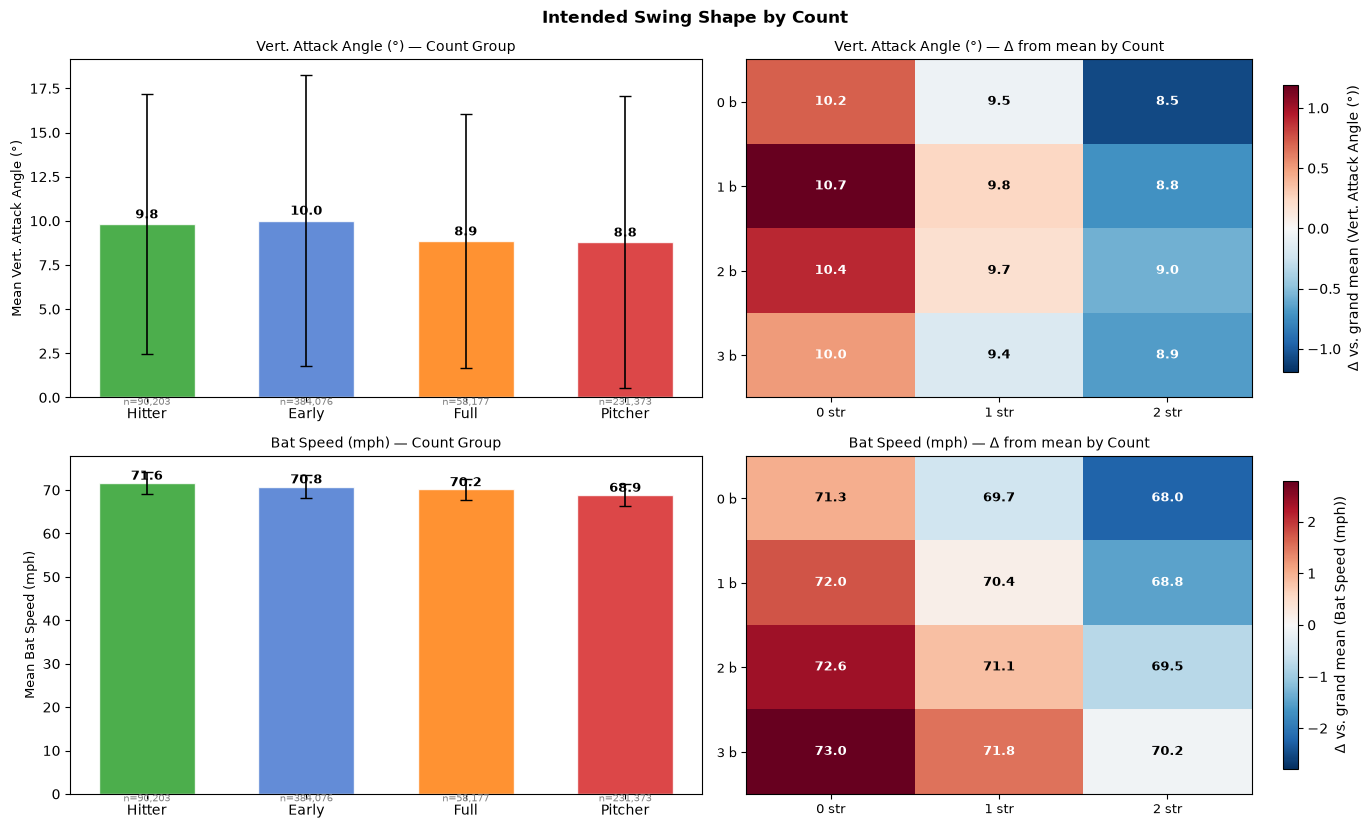

Saved results/plots/diagnostics/count_effects.png


In [7]:
LABELS = {"vert_attack_angle": "Vert. Attack Angle (\u00b0)", "bat_speed": "Bat Speed (mph)"}
COUNT_ORDER  = ["Hitter", "Early", "Full", "Pitcher"]
COUNT_COLORS = {"Hitter": "#2ca02c", "Early": "#4878d0",
                "Full": "#ff7f0e",   "Pitcher": "#d62728"}

sw   = pc()
intd = pd.read_parquet("models/intended_df.parquet")
df   = sw.join(intd)
df   = df[(df["is_swing"] == 1) & (df["bat_speed"] >= 50) &
          df["intended_vert_attack_angle"].notna()].copy()

metrics = ["vert_attack_angle", "bat_speed"]
fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 4.2 * len(metrics)))
fig.suptitle("Intended Swing Shape by Count", fontsize=12, fontweight="bold")

df_cg = df.dropna(subset=["count_group"])
df_cm = df[(df["balls"].between(0, 3)) & (df["strikes"].between(0, 2))].copy()

for r, resp in enumerate(metrics):
    lbl  = LABELS[resp]; icol = f"intended_{resp}"

    ax = axes[r, 0]
    grp   = df_cg.groupby("count_group")[icol]
    means = grp.mean().reindex(COUNT_ORDER); sds = grp.std().reindex(COUNT_ORDER)
    bars  = ax.bar(COUNT_ORDER, means.values,
                   color=[COUNT_COLORS[g] for g in COUNT_ORDER],
                   alpha=0.85, edgecolor="white", width=0.6)
    ax.errorbar(COUNT_ORDER, means.values, yerr=sds.values,
                fmt="none", color="black", capsize=4, lw=1.2)
    for bar, m, sd in zip(bars, means.values, sds.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sd*0.02,
                f"{m:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylabel(f"Mean {lbl}", fontsize=9)
    ax.set_title(f"{lbl} \u2014 Count Group", fontsize=10)
    ns = df_cg.groupby("count_group").size().reindex(COUNT_ORDER)
    for i, n in enumerate(ns):
        ax.text(i, ax.get_ylim()[0], f"n={n:,}", ha="center", va="top",
                fontsize=7, color="grey")

    ax = axes[r, 1]
    grand = df_cm[icol].mean()
    pivot = (df_cm.groupby(["balls", "strikes"])[icol].mean().subtract(grand)
             .unstack("strikes").reindex(index=[0,1,2,3], columns=[0,1,2]))
    raw   = (df_cm.groupby(["balls", "strikes"])[icol].mean()
             .unstack("strikes").reindex(index=[0,1,2,3], columns=[0,1,2]))
    vabs  = np.nanmax(np.abs(pivot.values))
    im = ax.imshow(pivot.values, cmap="RdBu_r", vmin=-vabs, vmax=vabs, aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.85, label=f"\u0394 vs. grand mean ({lbl})")
    for bi in range(4):
        for si in range(3):
            val = raw.iloc[bi, si]
            if not np.isnan(val):
                tc = "white" if abs(pivot.iloc[bi, si]) > vabs*0.4 else "black"
                ax.text(si, bi, f"{val:.1f}", ha="center", va="center",
                        fontsize=9, fontweight="bold", color=tc)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(["0 str", "1 str", "2 str"], fontsize=9)
    ax.set_yticks([0,1,2,3]); ax.set_yticklabels(["0 b","1 b","2 b","3 b"], fontsize=9)
    ax.set_title(f"{lbl} \u2014 \u0394 from mean by Count", fontsize=10)

fig.tight_layout()
out = "results/plots/diagnostics/count_effects.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out}")


# Fixed Effects

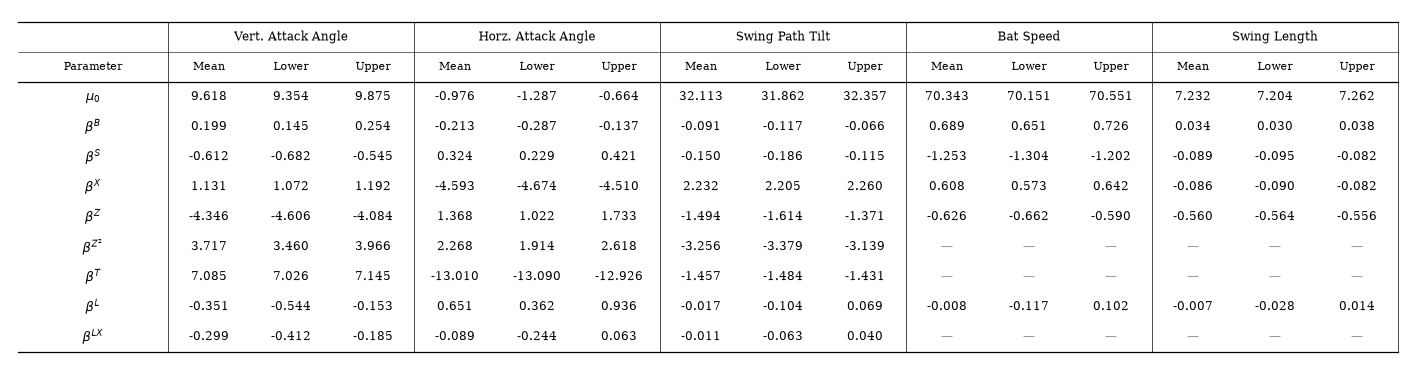

Saved results/plots/diagnostics/fixed_effects.png


In [8]:
RESPONSES = ["vert_attack_angle", "horz_attack_angle", "swing_path_tilt",
             "bat_speed", "swing_length"]
ANGULAR    = {"vert_attack_angle", "horz_attack_angle", "swing_path_tilt"}
PARAM_ORDER = ["Intercept", "scale(balls)", "scale(strikes)",
               "scale(plate_x_bat)", "scale(plate_z)", "scale(plate_z_sq)",
               "scale(offset_y_ms)", "pitcher_throws_L",
               "pitcher_throws_L:scale(plate_x_bat)"]
PARAM_GREEK = {
    "Intercept":                            r"$\mu_0$",
    "scale(balls)":                         r"$\beta^B$",
    "scale(strikes)":                       r"$\beta^S$",
    "scale(plate_x_bat)":                   r"$\beta^X$",
    "scale(plate_z)":                       r"$\beta^Z$",
    "scale(plate_z_sq)":                    r"$\beta^{Z^2}$",
    "scale(offset_y_ms)":                   r"$\beta^T$",
    "pitcher_throws_L":                     r"$\beta^L$",
    "pitcher_throws_L:scale(plate_x_bat)":  r"$\beta^{LX}$",
}
COL_GROUP = {"vert_attack_angle": "Vert. Attack Angle",
             "horz_attack_angle": "Horz. Attack Angle",
             "swing_path_tilt":   "Swing Path Tilt",
             "bat_speed":         "Bat Speed",
             "swing_length":      "Swing Length"}
RE_SFX    = ("_sigma", "_offset"); SKIP = {"sigma", "mu"}
ANG_ONLY  = {"scale(plate_z_sq)", "scale(offset_y_ms)",
             "pitcher_throws_L:scale(plate_x_bat)"}

result = joblib.load("models/intention_result.joblib")


def _fe(idata):
    post = idata.posterior; out = {}
    for v in post.data_vars:
        if (set(post[v].dims) == {"chain", "draw"} and v not in SKIP
                and not any(v.endswith(s) for s in RE_SFX)):
            draws = post[v].values.ravel()
            out[v] = {"mean": float(draws.mean()),
                      "lo":   float(np.percentile(draws, 2.5)),
                      "hi":   float(np.percentile(draws, 97.5))}
    return out


coefs = {r: _fe(result["idata"][r]) for r in RESPONSES}

LW=1.5; SW=0.82; RH=0.30; HH=0.30
ML=0.08; MR=0.08; MT=0.12; MB=0.12
NR=len(RESPONSES); NP=len(PARAM_ORDER)
fw = ML + LW + NR*3*SW + MR; fh = MT + 2*HH + NP*RH + MB
fig = plt.figure(figsize=(fw, fh)); ax = fig.add_axes([0,0,1,1])
ax.set_xlim(0, fw); ax.set_ylim(0, fh); ax.axis("off")

x0=ML; x1=fw-MR; yt=fh-MT; yg=yt-HH; ys=yg-HH; yb=MB
gx = lambda j: x0+LW+j*3*SW
cx = lambda j,k: gx(j)+(k+0.5)*SW

for y, lw in [(yt,0.9),(yg,0.4),(ys,0.9),(yb,0.9)]:
    ax.plot([x0,x1],[y,y],"k-",lw=lw)
for xv in [x0+LW]+[gx(j) for j in range(1,NR)]+[x1]:
    ax.plot([xv,xv],[yb,yt],"k-",lw=0.5)

for j,resp in enumerate(RESPONSES):
    ax.text(gx(j)+1.5*SW,(yt+yg)/2,COL_GROUP[resp],
            ha="center",va="center",fontsize=8.5,fontfamily="serif")
ax.text(x0+LW/2,(yg+ys)/2,"Parameter",ha="center",va="center",
        fontsize=8,fontfamily="serif")
for j in range(NR):
    for k,lbl in enumerate(["Mean","Lower","Upper"]):
        ax.text(cx(j,k),(yg+ys)/2,lbl,ha="center",va="center",
                fontsize=8,fontfamily="serif")
for i,param in enumerate(PARAM_ORDER):
    cy = ys-(i+0.5)*RH
    ax.text(x0+LW/2,cy,PARAM_GREEK[param],ha="center",va="center",
            fontsize=9,fontfamily="serif")
    for j,resp in enumerate(RESPONSES):
        if param in ANG_ONLY and resp not in ANGULAR:
            for k in range(3):
                ax.text(cx(j,k),cy,"\u2014",ha="center",va="center",
                        fontsize=8.5,color="#999",fontfamily="serif")
        else:
            s = coefs[resp].get(param)
            if s:
                for k,val in enumerate([s["mean"],s["lo"],s["hi"]]):
                    ax.text(cx(j,k),cy,f"{val:.3f}",ha="center",va="center",
                            fontsize=8.5,fontfamily="serif")
out = "results/plots/diagnostics/fixed_effects.png"
fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved {out}")


# 3D Trajectory

In [9]:
try:
    import plotly.graph_objects as go
except ImportError:
    raise ImportError("plotly not installed. Run: uv pip install plotly kaleido")

PITCH_COLORS = {"FF":"#d62728","SI":"#ff7f0e","FC":"#e377c2","CH":"#2ca02c",
                "FS":"#17becf","SL":"#bcbd22","CU":"#1f77b4","ST":"#9467bd","KC":"#1f77b4"}
PITCH_NAMES  = {"FF":"Four-seam fastball","SI":"Sinker","FC":"Cutter","CH":"Changeup",
                "FS":"Splitter","SL":"Slider","CU":"Curveball","ST":"Sweeper","KC":"Knuckle-curve"}
PITCHER_NAME = "Shohei Ohtani"
COMMIT_S = COMMIT_MS / 1000.0
PFX = f"pc{COMMIT_MS}_"
TRAJ = [f"{PFX}{c}" for c in ["R_x","R_y","R_z","V_x","V_y","V_z","A_x","A_y","A_z","t_plate"]]

df  = pc()
sub = df[(df["pitcher_full_name"] == PITCHER_NAME) &
         df[TRAJ].notna().all(axis=1) &
         df["pitch_type"].isin(PITCH_COLORS)].copy()
means = sub.groupby("pitch_type")[TRAJ].mean()


def _snap(Rx,Ry,Rz,Vx,Vy,Vz,Ax,Ay,Az,t_max):
    ts = np.arange(0, t_max+0.005/2, 0.005)
    return (Rx+Vx*ts+0.5*Ax*ts**2, Ry+Vy*ts+0.5*Ay*ts**2,
            Rz+Vz*ts+0.5*Az*ts**2, ts)


fig3d = go.Figure()
commit_ys = []
for pt in means.index:
    m = means.loc[pt]
    Rx,Ry,Rz = m[f"{PFX}R_x"],m[f"{PFX}R_y"],m[f"{PFX}R_z"]
    Vx,Vy,Vz = m[f"{PFX}V_x"],m[f"{PFX}V_y"],m[f"{PFX}V_z"]
    Ax,Ay,Az = m[f"{PFX}A_x"],m[f"{PFX}A_y"],m[f"{PFX}A_z"]
    t_plate  = m[f"{PFX}t_plate"]; t_c = t_plate - COMMIT_S
    x,y,z,ts = _snap(Rx,Ry,Rz,Vx,Vy,Vz,Ax,Ay,Az,t_plate)
    ci = int(np.searchsorted(ts, t_c)); color = PITCH_COLORS[pt]
    fig3d.add_trace(go.Scatter3d(x=x[:ci+1],y=y[:ci+1],z=z[:ci+1],mode="lines",
                               line=dict(color=color,width=5),opacity=0.5,
                               name=PITCH_NAMES.get(pt,pt),legendgroup=pt,showlegend=False))
    fig3d.add_trace(go.Scatter3d(x=x[ci:],y=y[ci:],z=z[ci:],mode="lines",
                               line=dict(color=color,width=9),legendgroup=pt,showlegend=False))
    fig3d.add_trace(go.Scatter3d(x=[float(x[-1])],y=[float(y[-1])],z=[float(z[-1])],
                               mode="markers",marker=dict(size=11,color=color),
                               legendgroup=pt,showlegend=False))
    xc=Rx+Vx*t_c+0.5*Ax*t_c**2; yc=Ry+Vy*t_c+0.5*Ay*t_c**2; zc=Rz+Vz*t_c+0.5*Az*t_c**2
    fig3d.add_trace(go.Scatter3d(x=[float(xc)],y=[float(yc)],z=[float(zc)],mode="markers",
                               marker=dict(size=14,color=color,line=dict(color="black",width=3)),
                               legendgroup=pt,showlegend=False))
    # legend-only trace: coloured dot with pitch name
    fig3d.add_trace(go.Scatter3d(x=[None],y=[None],z=[None],mode="markers",
                               marker=dict(size=10,color=color),
                               name=PITCH_NAMES.get(pt,pt),legendgroup=pt,showlegend=True))
    commit_ys.append(float(yc))

mcy = float(np.mean(commit_ys))
fig3d.add_trace(go.Scatter3d(x=[-1.,1.],y=[mcy,mcy],z=[2.5,2.5],mode="lines",
                           line=dict(color="rgba(0,0,0,0.45)",width=2,dash="dot"),
                           showlegend=False))
fig3d.add_trace(go.Scatter3d(x=[1.1],y=[mcy],z=[3.0],mode="text",
                           text=[f"  Decision point<br>  ({COMMIT_MS} ms)"],
                           textfont=dict(size=11,color="#1a1a1a"),showlegend=False))

_xg,_yg = np.meshgrid(np.linspace(-3,3,30), np.linspace(1.4,62,30))
fig3d.add_trace(go.Surface(x=_xg,y=_yg,z=np.zeros_like(_xg),
                         colorscale=[[0,"#4a7a34"],[1,"#4a7a34"]],
                         opacity=1,showscale=False,showlegend=False,hoverinfo="skip"))
_th,_r = np.meshgrid(np.linspace(0,2*np.pi,50), np.linspace(0,3,50))
fig3d.add_trace(go.Surface(x=_r*np.cos(_th),y=_r*np.sin(_th)+2,
                         z=np.full((50,50),0.005),
                         colorscale=[[0,"#c4a47c"],[1,"#c4a47c"]],
                         opacity=1,showscale=False,showlegend=False,hoverinfo="skip"))
_hp_x=[-8.5/12,8.5/12,10/12,0,-10/12,-8.5/12]
_hp_y=[2,2,1,0,1,2]; _hp_z=[0.01]*6
fig3d.add_trace(go.Mesh3d(x=_hp_x,y=_hp_y,z=_hp_z,
                        i=[0,1,2,2,3,4],j=[1,2,3,3,4,5],k=[5,5,5,4,5,0],
                        color="white",opacity=1,flatshading=True,
                        showlegend=False,hoverinfo="skip"))
fig3d.add_trace(go.Scatter3d(x=[-10/12,10/12,10/12,-10/12,-10/12],y=[2,2,2,2,2],
                           z=[1.5,1.5,3.5,3.5,1.5],mode="lines",
                           line=dict(color="#333333",width=5),showlegend=False))

fig3d.update_layout(
    scene=dict(
        xaxis=dict(range=[-3,3],showticklabels=False,showgrid=False,zeroline=False,
                   title="",backgroundcolor="white"),
        yaxis=dict(range=[0,62],showticklabels=False,showgrid=False,zeroline=False,
                   title="",backgroundcolor="white"),
        zaxis=dict(range=[0,6],showticklabels=False,showgrid=False,zeroline=False,
                   title="",backgroundcolor="white"),
        aspectmode="manual",aspectratio=dict(x=1,y=10,z=1),bgcolor="white"),
    scene_camera=dict(eye=dict(x=0.7,y=-5.75,z=0.1),
                      center=dict(x=0,y=5,z=-0.25),up=dict(x=0,y=0,z=1)),
    paper_bgcolor="white",width=1400,height=800,
    margin=dict(l=0,r=0,t=55,b=0),
    title=dict(text=f"{PITCHER_NAME} \u2014 Mean Pitch Trajectories by Type",
               font=dict(size=17,color="#1a1a1a"),x=0.5,xanchor="center"),
    legend=dict(font=dict(size=13,color="#1a1a1a"),bgcolor="rgba(240,240,240,0.9)",
                bordercolor="rgba(0,0,0,0.15)",borderwidth=1,
                x=0.72,y=0.05,itemsizing="constant"))
out = "results/plots/diagnostics/batter_view_3d.png"
fig3d.write_image(str(out), scale=2)
fig3d.show()
print(f"Saved {out}")


Saved results/plots/diagnostics/batter_view_3d.png
